In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from colossus.halo import profile_nfw
from colossus.cosmology import cosmology  
from colossus.halo import profile_einasto
from colossus.halo import concentration

# Set cosmology

In [10]:
# These simulations are described in this article:
# https://arxiv.org/pdf/2308.13461.pdf
# Haloes are estimated using Rockstar: https://arxiv.org/abs/1110.4372

In [11]:
cosmo_params = {
    'flat': True, 
    'H0': 70.0, 
    'Om0': 0.3, 
    'Ob0': 0.045, 
    'sigma8': 0.811, 
    'ns': 0.96
}
cosmology.addCosmology('MyCosmo', cosmo_params)
cosmo = cosmology.setCosmology('MyCosmo')

# Simulation details and particles

In [12]:
mp = 0.013398587e10 #particle mass
z = 0 # snapshot a redshift zero

In [13]:
path_halo = '/data/astro/scratch2/jcarrete/sandbox/Teaching/master_uab_ifae_ice/'
j = 12

## Halo particles

In [15]:
filename = path_halo+'halo_'+str(j)+'.hdf5'
print(filename)

/data/astro/scratch2/jcarrete/sandbox/Teaching/master_uab_ifae_ice/halo_12.hdf5


In [16]:
halo = h5py.File(filename,'r') 

X = np.array(halo['X']) - halo.attrs['x0']
Y = np.array(halo['Y']) - halo.attrs['y0']
Z = np.array(halo['Z']) - halo.attrs['z0']

## Particles within 10Mpc box

In [17]:
filename = path_halo+'halo_'+str(j)+'_10Mpc.hdf5'
print(filename)

/data/astro/scratch2/jcarrete/sandbox/Teaching/master_uab_ifae_ice/halo_12_10Mpc.hdf5


In [18]:
allp = h5py.File(path_halo+'halo_'+str(j)+'_10Mpc.hdf5','r') 

Xp = np.array(allp['X']) - allp.attrs['x0 center']
Yp = np.array(allp['Y']) - allp.attrs['y0 center']
Zp = np.array(allp['Z']) - allp.attrs['z0 center']

## Plotting

### Only the particles of the halo

In [19]:
view_points = np.array([-140, 60])

Making plot...


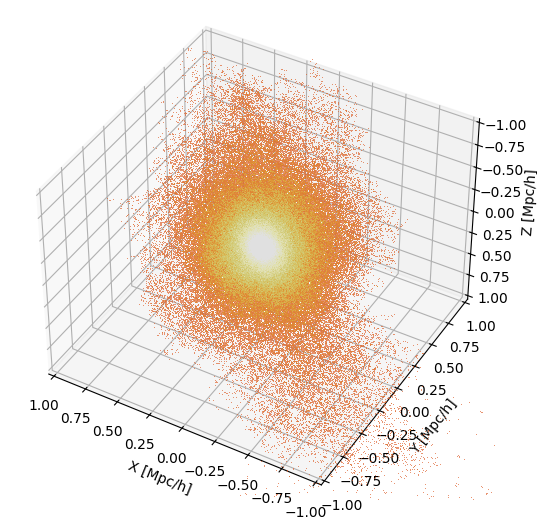

In [20]:
print('Making plot...')
fig = plt.figure(figsize=(14,14))
ax = fig.add_subplot(2,2,1,projection='3d')
# 'C3,' ---> C3 es un color y la coma, el pto. es un píxel. 
# Es la unidad más pequeña para plotear
ax.plot(X,Y,Z,'C3,',alpha=0.5) # Rojo
ax.plot(X,Y,Z,'C1,',alpha=0.2) # Naranja 
ax.plot(X,Y,Z,'C8,',alpha=0.1) # Amarillo
ax.plot(X,Y,Z,'w,',alpha=0.03) # Blanco
ax.set_xlabel('X [Mpc/h]')
ax.set_ylabel('Y [Mpc/h]')
ax.set_zlabel('Z [Mpc/h]')
ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
ax.set_zlim(-1,1)
ax.view_init(view_points[0], view_points[1])

In [21]:
view_points = np.array([30, -140])

Making plot...


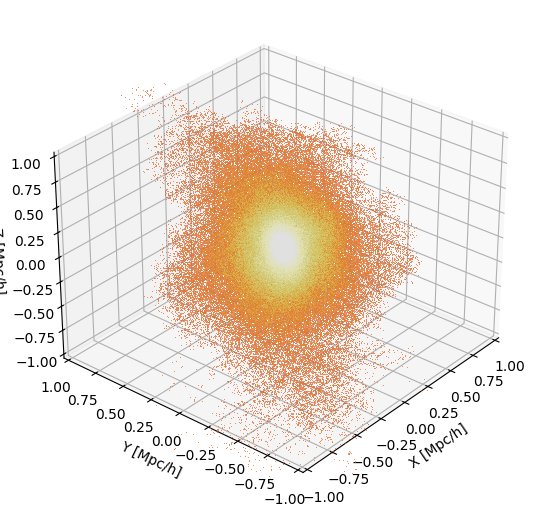

In [22]:
print('Making plot...')
fig = plt.figure(figsize=(14,14))
ax = fig.add_subplot(2,2,1,projection='3d')
ax.plot(X,Y,Z,'C3,',alpha=0.5)
ax.plot(X,Y,Z,'C1,',alpha=0.2)
ax.plot(X,Y,Z,'C8,',alpha=0.1)
ax.plot(X,Y,Z,'w,',alpha=0.03)
ax.set_xlabel('X [Mpc/h]')
ax.set_ylabel('Y [Mpc/h]')
ax.set_zlabel('Z [Mpc/h]')
ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
ax.set_zlim(-1,1)
ax.view_init(view_points[0], view_points[1])

In [23]:
view_points = np.array([60, 160])

Making plot...


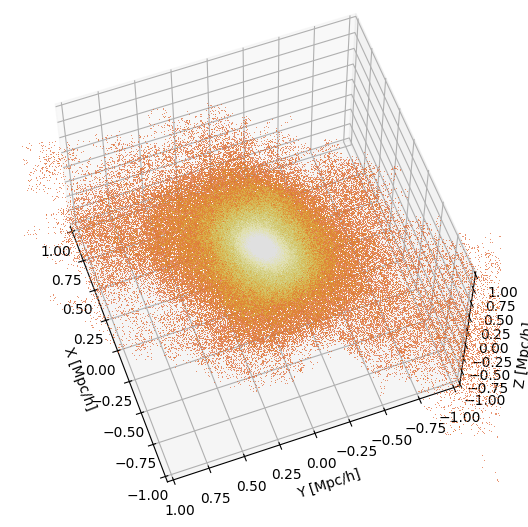

In [24]:
print('Making plot...')
fig = plt.figure(figsize=(14,14))
ax = fig.add_subplot(2,2,1,projection='3d')
ax.plot(X,Y,Z,'C3,',alpha=0.5)
ax.plot(X,Y,Z,'C1,',alpha=0.2)
ax.plot(X,Y,Z,'C8,',alpha=0.1)
ax.plot(X,Y,Z,'w,',alpha=0.03)
ax.set_xlabel('X [Mpc/h]')
ax.set_ylabel('Y [Mpc/h]')
ax.set_zlabel('Z [Mpc/h]')
ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
ax.set_zlim(-1,1)
ax.view_init(view_points[0], view_points[1])

In [25]:
view_points = np.array([30, -160])

Making plot...


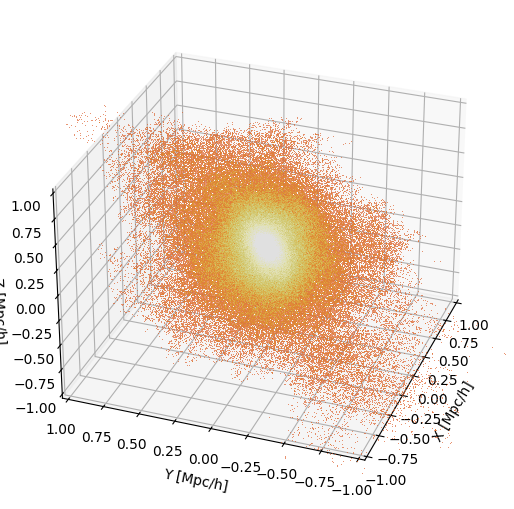

In [26]:
print('Making plot...')
fig = plt.figure(figsize=(14,14))
ax = fig.add_subplot(2,2,1,projection='3d')
ax.plot(X,Y,Z,'C3,',alpha=0.5)
ax.plot(X,Y,Z,'C1,',alpha=0.2)
ax.plot(X,Y,Z,'C8,',alpha=0.1)
ax.plot(X,Y,Z,'w,',alpha=0.03)
ax.set_xlabel('X [Mpc/h]')
ax.set_ylabel('Y [Mpc/h]')
ax.set_zlabel('Z [Mpc/h]')
ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
ax.set_zlim(-1,1)
ax.view_init(view_points[0], view_points[1])

### Position of the halo within the 10Mpc box

Making plot...


Text(0.5, 0, 'Z [Mpc]')

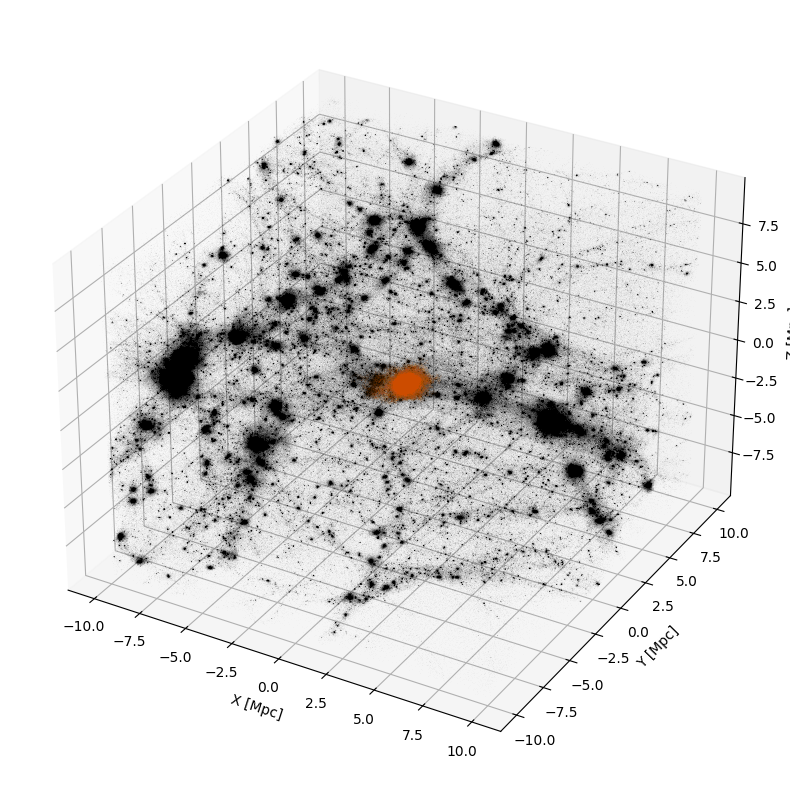

In [27]:
print('Making plot...')
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection='3d')
ax.plot(Xp,Yp,Zp,'k,',alpha=0.01)
ax.plot(X,Y,Z,'C1,',alpha=0.02)
ax.set_xlabel('X [Mpc]')
ax.set_ylabel('Y [Mpc]')
ax.set_zlabel('Z [Mpc]')

In [28]:
len(Xp),len(X)

(9484852, 313404)

# Estimating the mass and the virial radius (Rvir) according to the particles

#### Mass of the total bounded dark matter particles

In [29]:
Mtot = len(X)*mp
print('M = ', Mtot/1.e13,'x 10^13 M_sun')

M =  4.199170760148 x 10^13 M_sun


In [32]:
# https://bdiemer.bitbucket.io/colossus/halo_concentration.html#halo.concentration.concentration
# https://bdiemer.bitbucket.io/colossus/halo_profile_nfw.html

In [34]:
cvir = concentration.concentration(Mtot, 'vir', 0.0, model = 'diemer15') # the third argument is the redshift
pNFW = profile_nfw.NFWProfile(M = Mtot, mdef = 'vir', z = 0, c = cvir)

In [39]:
# pNFW tiene todos los parámetros de un perfil de densidad.
# RDelta es un atributo de pNFW para una cierta sobre-densidad.
# También le puedes decir cuál es el radio a un valor de una sobre-densidad.
# Rvir normalmente corresponde a un Delta de 180 veces la densidad crítica
Rvir_estimated = pNFW.RDelta(0, 'vir')/1.e3
print(Rvir_estimated, 'Mpc')

0.7094793357436974 Mpc


In [40]:
Rvir_estimated = pNFW.RDelta(0, '200c')/1.e3
print(Rvir_estimated, 'Mpc')

0.5287891261056821 Mpc


In [41]:
Rvir_estimated = pNFW.RDelta(0, '180c')/1.e3
print(Rvir_estimated, 'Mpc')

0.5537294691721757 Mpc


In [42]:
Rvir_estimated = pNFW.RDelta(0, '180m')/1.e3
print(Rvir_estimated, 'Mpc')

0.9226279507040239 Mpc


In [43]:
Rvir_estimated = pNFW.RDelta(0, '200m')/1.e3
print(Rvir_estimated, 'Mpc')

0.8832278204339968 Mpc


# Computing 3D density profiles
#### (Using the dark matter particles)

In [44]:
def rho_r(X,Y,Z,rin=0.1,rmax=1.,nrings=50):
    
    
    step = (rmax-rin)/float(nrings)    

    rho_p = np.zeros(nrings)
    R  = np.zeros(nrings)

    ring = 0 # Estimating the number of DM particles in spherical shells

    while ring < nrings:

        r_in  = rin
        r_out = (rin+step)
        r_med = (rin + 0.5*step)
        R[ring] = r_med

        r_part = np.sqrt(X**2+ Y**2 + Z**2)
        mask = (r_part >= r_in)*(r_part < r_out) # Taking into account only the DM particles in the distance range
        
        V = (4./3.)*np.pi*(r_out**3 - r_in**3)

        rho_p[ring] = (mask.sum()*mp)/V

        rin += step
        ring += 1

    rho = rho_p/(1.e3**3)
    
    return R,rho

In [48]:
R,rho = rho_r(X,Y,Z, rmax=5., nrings=100) # Halo profile
R_all,rho_all = rho_r(Xp,Yp,Zp,rmax=5., nrings=100) # Using all the particles

Text(0, 0.5, '$\\rho [Msun/pc^2]$')

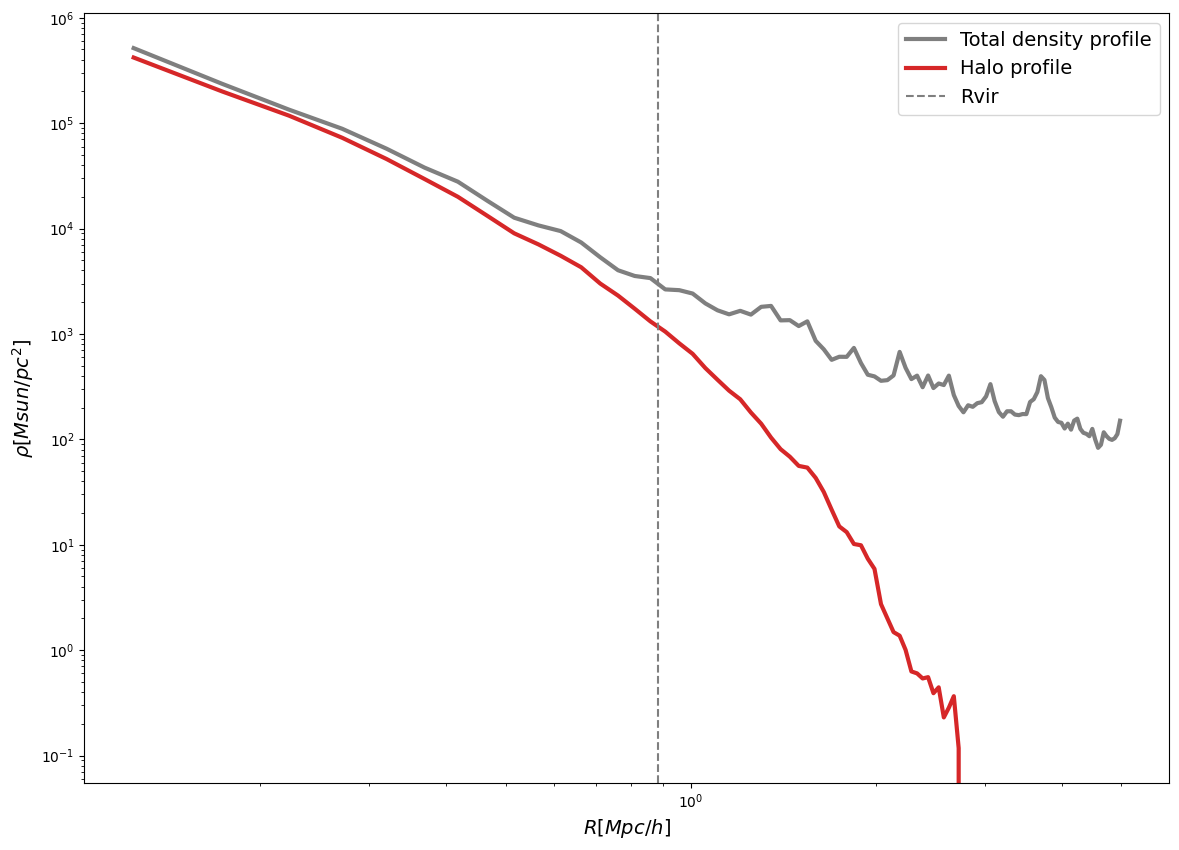

In [49]:
plt.figure(figsize=(14,10))
plt.plot(R_all,rho_all,'C7',label='Total density profile',lw=3)
plt.plot(R,rho,'C3',label='Halo profile',lw=3)
plt.axvline(Rvir_estimated,color='C7',ls='--',label='Rvir')
plt.legend(fontsize=14)
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'$R [Mpc/h]$',fontsize=14)
plt.ylabel(r'$\rho [Msun/pc^2]$',fontsize=14)

# Fit model to the profiles

#### These functions are defined in order to be optimize using scipy

In [52]:
def rho_nfw(R,log_M200,c200):

    pNFW = profile_nfw.NFWProfile(M = 10**log_M200, mdef = '200c', z = z, c = c200)
    return pNFW.density(R*1.e3)

In [53]:
def rho_einasto(R,log_M200,c200,alpha):
    pEin = profile_einasto.EinastoProfile(M = 10**log_M200, mdef = '200c', z = z, c = c200, alpha = alpha)
    return pEin.density(R*1.e3)

In [59]:
# El valor de la concentración depende mucho del rango radial.
# Es decir, si cambio los ptos inicial y final, podría cambiar
# Einasto suele ser más robusto en cuanto a la estimación de la concentración, 
# aunque tiene un parámetro más

In [54]:
# Range of the parameters:
# log10 (mass) between 10 and 16
# the concentration between 1 and 10
bounds = [[10,1],[16,10]]
params_nfw = curve_fit(rho_nfw,
                   R[R<Rvir],
                   rho[R<Rvir],
                   absolute_sigma = True,
                   bounds = bounds
                  )[0]

In [55]:
# In Einasto there is another parameter:
# alpha between 0 and 1.5
bounds = [[10,1,0],[16,12,1.5]]
params_einasto = curve_fit(rho_einasto,
                   R[R<Rvir],
                   rho[R<Rvir],
                   absolute_sigma = True,
                   bounds = bounds
                  )[0]

In [56]:
params_einasto, params_nfw

(array([13.48589444,  4.48567811,  0.29205074]),
 array([13.5092958 ,  5.39062171]))

Text(0, 0.5, '$\\rho [Msun/pc^2]$')

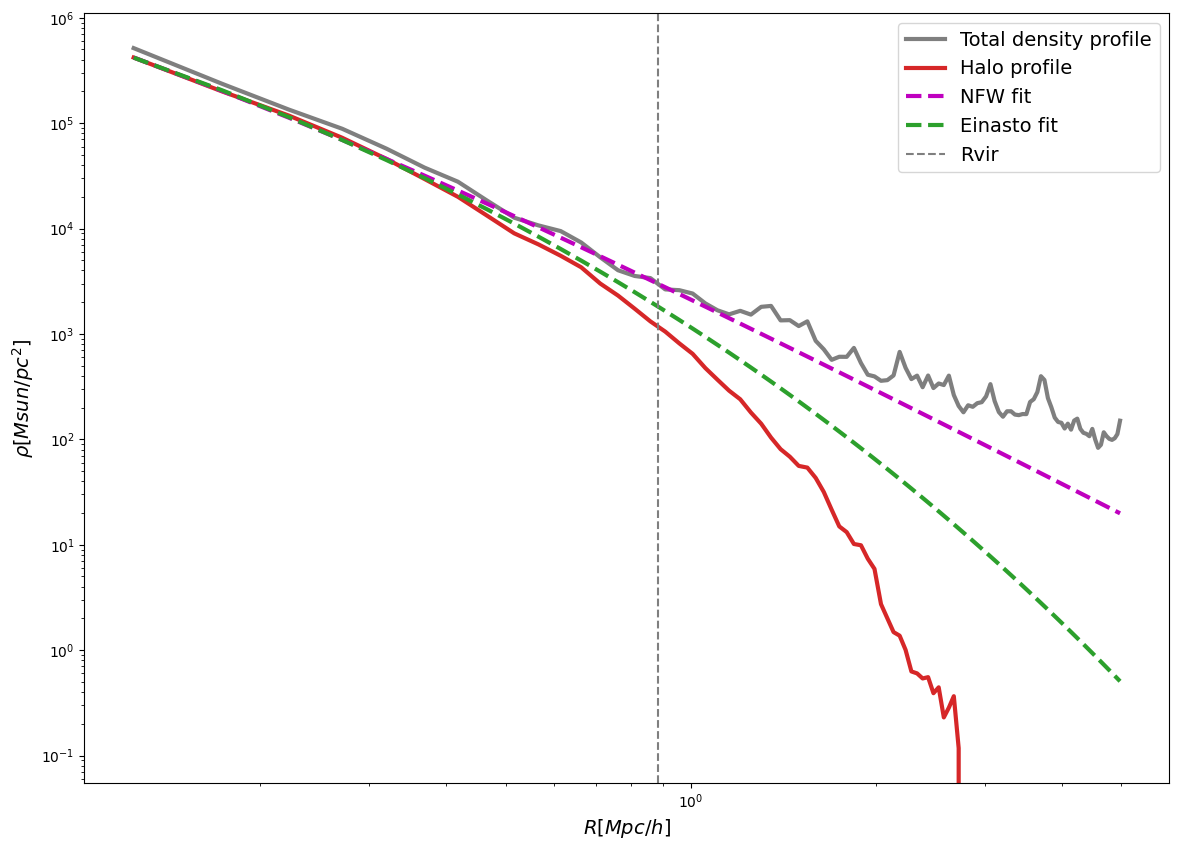

In [58]:
plt.figure(figsize=(14,10))
plt.plot(R_all,rho_all,'C7',label='Total density profile',lw=3)
plt.plot(R,rho,'C3',label='Halo profile',lw=3)
plt.plot(R,rho_nfw(R,*params_nfw),'m--',label='NFW fit',lw=3)
plt.plot(R,rho_einasto(R,*params_einasto),'C2--',label='Einasto fit',lw=3)
plt.axvline(Rvir_estimated,color='C7',ls='--',label='Rvir')
plt.legend(fontsize=14)
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'$R [Mpc/h]$',fontsize=14)
plt.ylabel(r'$\rho [Msun/pc^2]$',fontsize=14)